# 01 — Data Exploration (EDA)

EDA всех 3 модальностей. Автодетект валидных тикеров.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pyarrow
!apt-get install -q git-lfs && git lfs install

Mounted at /content/drive
Reading package lists...
Building dependency tree...
Reading state information...
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
Git LFS initialized.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import zipfile
import gc
import os
from pathlib import Path
from collections import defaultdict, Counter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DRIVE_ROOT = Path('/content/drive/MyDrive/predictamarket')
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
EDA_DIR = DRIVE_ROOT / 'eda'
EDA_DIR.mkdir(exist_ok=True)

print(f'Drive: {DRIVE_ROOT}')

Drive: /content/drive/MyDrive/predictamarket


## Clone dataset

In [3]:
DATASET_ROOT = Path('/content/dataset')

if not DATASET_ROOT.exists():
    !git clone https://huggingface.co/datasets/Wenyan0110/Multimodal-Dataset-Image_Text_Table_TimeSeries-for-Financial-Time-Series-Forecasting /content/dataset
    print('Dataset cloned.')
else:
    print('Dataset already present.')

ts_dir = DATASET_ROOT / 'time_series' / 'S&P500_time_series'
news_dir = DATASET_ROOT / 'text' / 'sp500_news'
zip_path = DATASET_ROOT / 'table' / 'SP500_tabular.zip'

!du -sh /content/dataset

Cloning into '/content/dataset'...
remote: Enumerating objects: 146877, done.
remote: Total 146877 (delta 0), reused 0 (delta 0), pack-reused 146877 (from 1)
Receiving objects: 100% (146877/146877), 20.06 MiB | 16.86 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Updating files: 100% (142480/142480), done.
Filtering content: 100% (142475/142475), 14.71 GiB | 7.46 MiB/s, done.
Dataset cloned.
31G	/content/dataset


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
from pathlib import Path

DATASET = Path('/content/dataset')

archives = {
    'time_series/S&P500_time_series.zip': 'time_series/',
    'text/sp500_news.zip': 'text/',
    'table/SP500_tabular.zip': 'table/',
}

for zip_rel, extract_to in archives.items():
    zip_path = DATASET / zip_rel
    target = DATASET / extract_to
    if zip_path.exists():
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(target)
        print(f'  Done → {target}')
    else:
        print(f'  Skip: {zip_path.name} not found')

print('\n=== Extracted ===')
!ls /content/dataset/time_series/ | head -5
!ls /content/dataset/time_series/S&P500_time_series/ | head -5
!ls /content/dataset/text/sp500_news/ | head -5
!ls /content/dataset/table/financial_reports/ | head -5
!du -sh /content/dataset/


Extracting S&P500_time_series.zip...
  Done → /content/dataset/time_series
Extracting sp500_news.zip...
  Done → /content/dataset/text
Extracting SP500_tabular.zip...
  Done → /content/dataset/table

=== Extracted ===
HS300_time_series.zip
S&P500_time_series
S&P500_time_series.zip
/bin/bash: line 1: P500_time_series/: No such file or directory
ls: cannot access '/content/dataset/time_series/S': No such file or directory
AAAU.jsonl
AACG.jsonl
AADR.jsonl
AA.jsonl
AAL.jsonl
aa
aaau
aacg
aal
aame
130G	/content/dataset/


In [8]:
import os

ts_dir = '/content/dataset/time_series/S&P500_time_series'
news_dir = '/content/dataset/text/sp500_news'
table_dir = '/content/dataset/table/financial_reports'

ts_count = len([f for f in os.listdir(ts_dir) if f.endswith('.csv')])
news_count = len([f for f in os.listdir(news_dir) if f.endswith('.jsonl')])
table_count = len(os.listdir(table_dir))

print(f'Time series CSVs: {ts_count}')
print(f'News JSONL files: {news_count}')
print(f'Table directories: {table_count}')
print(f'\nDisk free:')
!df -h /content | tail -1


Time series CSVs: 4213
News JSONL files: 4694
Table directories: 2676

Disk free:
overlay         226G  151G   76G  67% /


## Auto-detect valid tickers

In [10]:
meta = pd.read_csv(DATASET_ROOT / 'sp500stock_data_description.csv')
print(f'Total in metadata: {len(meta)}')

has_all_flags = meta[(meta['ts'] == 1) & (meta['text'] == 1) & (meta['table'] == 1)]
print(f'With all 3 modality flags: {len(has_all_flags)}')

# Verify actual files
ts_files = set(f.replace('.csv', '') for f in os.listdir(ts_dir) if f.endswith('.csv'))
news_files = set(f.replace('.jsonl', '').lower() for f in os.listdir(news_dir) if f.endswith('.jsonl'))

with zipfile.ZipFile(zip_path, 'r') as z:
    zip_tickers = set()
    for name in z.namelist():
        parts = name.split('/')
        if len(parts) >= 3 and parts[0] == 'financial_reports' and parts[2].endswith('.json'):
            zip_tickers.add(parts[1])

print(f'Files: TS={len(ts_files)}, News={len(news_files)}, Tables(ZIP)={len(zip_tickers)}')

TICKERS = sorted([
    row['stock_name'] for _, row in has_all_flags.iterrows()
    if row['stock_name'] in ts_files
    and row['stock_name'] in news_files
    and row['stock_name'] in zip_tickers
])

SECTORS = dict(zip(meta['stock_name'], meta['Sector']))
SECTORS = {t: SECTORS.get(t, 'N/A') for t in TICKERS}

print(f'\nValidated tickers: {len(TICKERS)}')
sector_counts = Counter(SECTORS.values())
for sector, count in sector_counts.most_common():
    print(f'  {sector}: {count}')

Total in metadata: 4213
With all 3 modality flags: 2676
Files: TS=4213, News=4694, Tables(ZIP)=2676

Validated tickers: 2638
  Healthcare: 471
  Financial Services: 423
  Industrials: 329
  Technology: 327
  Consumer Cyclical: 276
  Real Estate: 154
  Energy: 145
  Basic Materials: 127
  Consumer Defensive: 116
  Communication Services: 104
  nan: 103
  Utilities: 63


## Time series overview

,ticker,rows,date_min,date_max,close_mean
0,aa,6348,2000-01-03,2025-03-28,40.27
1,adp,6348,2000-01-03,2025-03-28,79.41
2,aihs,1768,2018-03-19,2025-03-28,12.25
3,amed,6348,2000-01-03,2025-03-28,57.40
4,appf,2454,2015-06-26,2025-03-28,106.24
5,asur,6348,2000-01-03,2025-03-28,8.99
6,azo,6348,2000-01-03,2025-03-28,702.78
7,bery,3138,2012-10-04,2025-03-28,42.27
8,bmo,6348,2000-01-03,2025-03-28,41.37
9,btu,2009,2017-04-03,2025-03-28,19.93


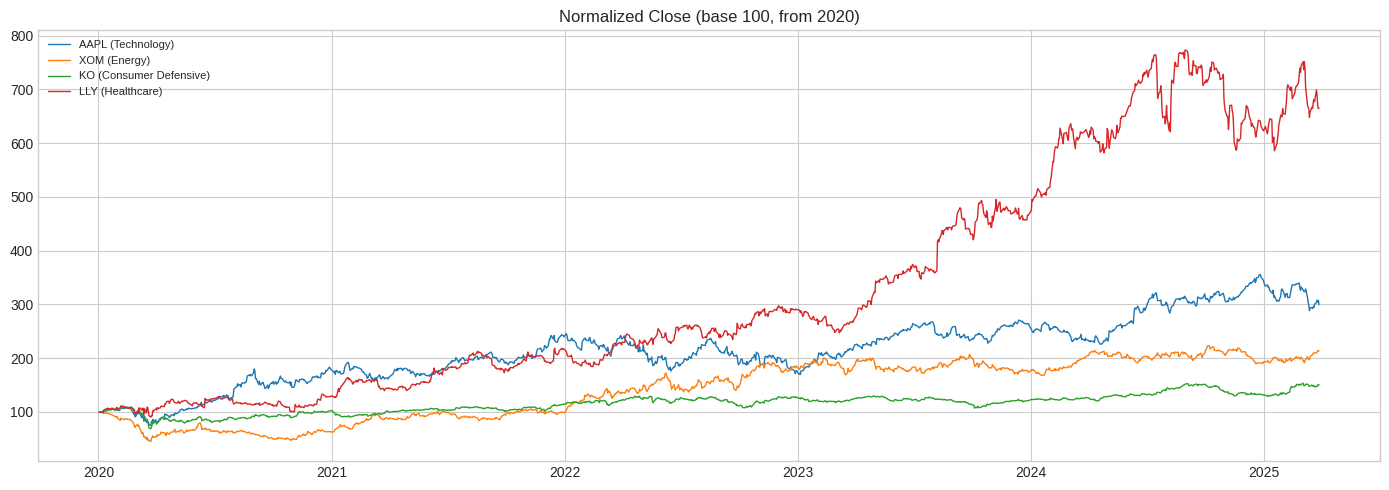

In [ ]:
from pathlib import Path

ts_dir = Path('/content/dataset/time_series/S&P500_time_series')
news_dir = Path('/content/dataset/text/sp500_news')
table_dir = Path('/content/dataset/table/financial_reports')

sample_tickers = TICKERS[::max(1, len(TICKERS)//50)]
ts_summary = []

for ticker in sample_tickers[:15]:
    df = pd.read_csv(ts_dir / f'{ticker}.csv')
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    ts_summary.append({
        'ticker': ticker, 'rows': len(df),
        'date_min': str(df['Date'].min().date()),
        'date_max': str(df['Date'].max().date()),
        'close_mean': round(df['Close'].mean(), 2),
    })
    del df; gc.collect()

display(pd.DataFrame(ts_summary))

fig, ax = plt.subplots(figsize=(14, 5))
for ticker in ['aapl', 'jpm', 'xom', 'ko', 'lly']:
    if ticker in TICKERS:
        df = pd.read_csv(ts_dir / f'{ticker}.csv')
        df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
        df = df[df['Date'] >= '2020-01-01']
        if len(df) > 0:
            norm = df['Close'] / df['Close'].iloc[0] * 100
            ax.plot(df['Date'], norm, label=f"{ticker.upper()} ({SECTORS[ticker]})", lw=1)
        del df
ax.set_title('Normalized Close (base 100, from 2020)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(EDA_DIR / 'price_overview.png', dpi=100)
plt.show()


## News and tables overview

In [ ]:
news_counts = {}
for ticker in sample_tickers:
    fpath = news_dir / f'{ticker.upper()}.jsonl'
    if fpath.exists():
        with open(fpath) as f:
            news_counts[ticker] = sum(1 for line in f if line.strip())
    else:
        news_counts[ticker] = 0

counts = list(news_counts.values())
print(f'News (sampled {len(sample_tickers)} tickers):')
print(f'  min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.0f}')

print(f'\nTables: {len(os.listdir(table_dir))} ticker directories (extracted)')
!du -sh {table_dir}

REPORT_TYPES = [
    'condensed_consolidated_balance_sheets',
    'condensed_consolidated_statement_of_cash_flows',
    'condensed_consolidated_statement_of_equity'
]
metric_counts = Counter()
for ticker in sample_tickers:
    ticker_path = table_dir / ticker
    if not ticker_path.exists():
        continue
    for rt in REPORT_TYPES:
        json_path = ticker_path / f'{rt}.json'
        if not json_path.exists():
            continue
        try:
            with open(json_path) as f:
                data = json.load(f)
            for filing in data.get('filings', []):
                for m in filing.get('facts', {}).get('us-gaap', {}):
                    metric_counts[m] += 1
            del data
        except:
            pass

threshold = len(sample_tickers) * 0.8
common_metrics = [m for m, c in metric_counts.most_common() if c >= threshold]
print(f'\nCommon metrics (80%+ tickers): {len(common_metrics)}')
for m in common_metrics[:15]:
    print(f'  {m}')


News (sampled 51 tickers):
  min=7, max=1865, mean=513

Tables: 2676 ticker directories (extracted)
85G	/content/dataset/table/financial_reports

Common metrics (80%+ tickers): 27
  CommonStockValue
  Assets
  StockholdersEquity
  NetCashProvidedByUsedInFinancingActivities
  NetCashProvidedByUsedInInvestingActivities
  NetCashProvidedByUsedInOperatingActivities
  RetainedEarningsAccumulatedDeficit
  PropertyPlantAndEquipmentNet
  CashAndCashEquivalentsPeriodIncreaseDecrease
  PaymentsToAcquirePropertyPlantAndEquipment
  AssetsCurrent
  LiabilitiesCurrent
  Liabilities
  AccountsPayableCurrent
  AccountsReceivableNetCurrent


## Sector distribution

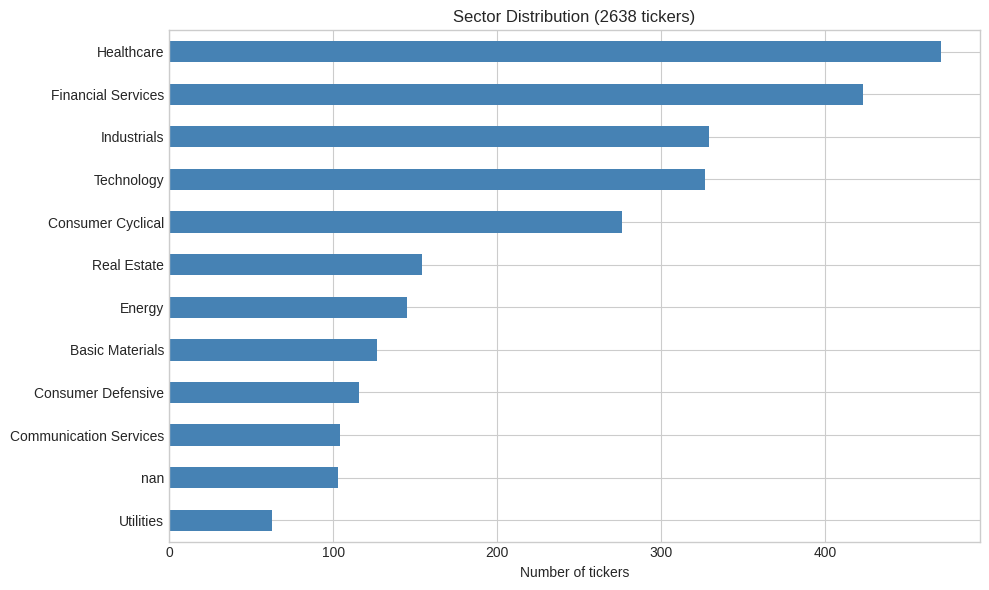

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
pd.Series(sector_counts).sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Number of tickers')
ax.set_title(f'Sector Distribution ({len(TICKERS)} tickers)')
plt.tight_layout()
plt.savefig(EDA_DIR / 'sectors.png', dpi=100)
plt.show()

## Save config to Drive

In [18]:
MACRO_TICKERS = {
    '^VIX': 'VIX', '^TNX': '10Y Treasury', '^GSPC': 'S&P 500',
    'DX-Y.NYB': 'Dollar Index', 'GC=F': 'Gold', 'CL=F': 'Oil',
}

config = {
    'tickers': TICKERS,
    'sectors': SECTORS,
    'num_tickers': len(TICKERS),
    'dataset_path': str(DATASET_ROOT),
    'table_dir': str(table_dir),
    'common_table_metrics': common_metrics,
    'report_types': REPORT_TYPES,
    'macro_tickers': MACRO_TICKERS,
    'n_sentiment_components': 32,
    'max_encoder_length': 120,
    'max_prediction_length': 22,
}

with open(DRIVE_ROOT / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

with open(DRIVE_ROOT / 'tickers.txt', 'w') as f:
    f.write('\n'.join(TICKERS))

print(f'=== EDA Complete ===')
print(f'Tickers: {len(TICKERS)}')
print(f'Sectors: {len(set(SECTORS.values()))}')
print(f'Common metrics: {len(common_metrics)}')
print(f'\nConfig saved to: {DRIVE_ROOT / "config.json"}')
print(f'\nНе отключай Colab — датасет уже на диске.')
print(f'Открой 02_preprocessing.ipynb и запусти в этой же сессии.')

=== EDA Complete ===
Tickers: 2638
Sectors: 12
Common metrics: 27

Config saved to: /content/drive/MyDrive/predictamarket/config.json

Не отключай Colab — датасет уже на диске.
Открой 02_preprocessing.ipynb и запусти в этой же сессии.
